<a href="https://colab.research.google.com/github/Ajwad07/ML_projects_/blob/main/Stylized_Scene_Memory_Recall_Simplified_Version_V3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
Reconstruct real images using a caption and a blurred version of the image
```



V3-----> added VGG loss

In [1]:
# Install Hugging Face Transformers (for text encoder)
# Skip this in Kaggle if already installed
!pip install transformers --quiet



In [2]:
import os
import json

# Create a folder to hold COCO files
os.makedirs('coco', exist_ok=True)

# Download COCO validation images
if not os.path.exists('coco/val2017'):
    !wget -q -O coco/val2017.zip http://images.cocodataset.org/zips/val2017.zip
    !unzip -q coco/val2017.zip -d coco/

# Download COCO captions (annotations)
if not os.path.exists('coco/annotations'):
    !wget -q -O coco/annotations_trainval2017.zip http://images.cocodataset.org/annotations/annotations_trainval2017.zip
    !unzip -q coco/annotations_trainval2017.zip -d coco/


In [3]:
import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision import models, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageFilter
from transformers import BertTokenizer, BertModel
import os


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# Load COCO captions JSON
with open('coco/annotations/captions_val2017.json', 'r') as f:
    captions_data = json.load(f)

# Build mapping: image_id → captions[]
img_id_to_captions = {}
for ann in captions_data['annotations']:
    img_id_to_captions.setdefault(ann['image_id'], []).append(ann['caption'])

# Select 10,000 image paths
NUM_IMAGES = 100
img_files = sorted(os.listdir('coco/val2017'))[:NUM_IMAGES]
image_paths = ['coco/val2017/' + fname for fname in img_files]
image_ids = [int(fname.split('.')[0]) for fname in img_files]
# captions = [img_id_to_captions.get(i, ['No caption'])[0] for i in image_ids]
captions = [img_id_to_captions.get(i, ['No caption']) for i in image_ids]


In [5]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Simple blur function using PIL
def blur_image(img_tensor):
    img = transforms.ToPILImage()(img_tensor)
    blurred = img.filter(ImageFilter.GaussianBlur(radius=1.5))
    return transform(blurred)

In [ ]:
# # Download a small dummy dataset (we'll use this first instead of full COCO)
# dataset = datasets.CocoCaptions(
#     root='./coco/images/train2017',
#     annFile='./coco/annotations/captions_train2017.json',
#     transform=T.Compose([
#         T.Resize((128, 128)),
#         T.ToTensor()
#     ])
# )

# # Load only a few images for now to keep it lightweight
# small_dataset = torch.utils.data.Subset(dataset, range(100))  # Use only first 100 samples
# loader = DataLoader(small_dataset, batch_size=4, shuffle=True)


In [ ]:
from transformers import BertTokenizer, BertModel
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert = BertModel.from_pretrained('bert-base-uncased').to(device)

def encode_caption(captions_batch):
    enc = tokenizer(captions_batch, padding=True, truncation=True, return_tensors="pt").to(device)
    with torch.no_grad():
        output = bert(**enc)
    return output.last_hidden_state.mean(dim=1)  # [B, 768]

For all 5 caps


In [8]:
from transformers import BertTokenizer, BertModel
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert = BertModel.from_pretrained('bert-base-uncased').to(device)

def encode_caption(captions_batch):
    # Process each list of captions for each image
    all_embeddings = []
    for captions_list in captions_batch:
        # Encode each caption in the list
        enc = tokenizer(captions_list, padding=True, truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            output = bert(**enc)
        # Average the embeddings for the captions of a single image
        avg_embedding = output.last_hidden_state.mean(dim=1).mean(dim=0) # Average over tokens and then over captions
        all_embeddings.append(avg_embedding)
    return torch.stack(all_embeddings) # Stack the averaged embeddings

In [9]:
from torchvision import models
import torch.nn as nn

resnet = models.resnet18(pretrained=True).to(device) # Moved resnet to device
resnet = nn.Sequential(*list(resnet.children())[:-2])  # remove FC
resnet.eval()
for p in resnet.parameters():
    p.requires_grad = False

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 77.7MB/s]


In [10]:
class DecoderUNet(nn.Module):
    def __init__(self, in_channels=512+768):  # ResNet + BERT
        super().__init__()
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels, 256, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), # Added this layer
            nn.ReLU(), # Added activation for the new layer
            nn.ConvTranspose2d(32, 3, 4, 2, 1), # This should upsample to 128x128
            nn.Sigmoid()
        )

    def forward(self, img_feat, text_feat):
        B, C, H, W = img_feat.shape
        text_feat = text_feat.view(B, -1, 1, 1).expand(-1, -1, H, W)
        x = torch.cat([img_feat, text_feat], dim=1)
        return self.decoder(x)

In [15]:
# Perceptual Loss using pretrained VGG
from torchvision.models import vgg16
vgg = vgg16(pretrained=True).features[:16].eval().to(device) # Moved vgg to device
for p in vgg.parameters(): p.requires_grad = False

def perceptual_loss(pred, target):
    pred_vgg = vgg(pred)
    target_vgg = vgg(target)
    return torch.nn.functional.mse_loss(pred_vgg, target_vgg)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [28]:
model = DecoderUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
# loss_fn = nn.L1Loss()
l1_loss = nn.L1Loss()
# loss = 0.5 * l1_loss() + 0.5 * perceptual_loss() # This line caused the error
loss_fn = lambda p, t: 0.9 * l1_loss(p, t) + 0.1* perceptual_loss(p, t)


# Simple training loop (demo only)
for step in range(1000):
    idx = torch.randint(0, NUM_IMAGES, (4,))
    imgs = [Image.open(image_paths[i]).convert("RGB") for i in idx]
    raw_tensors = torch.stack([transform(im) for im in imgs]).to(device)
    blur_tensors = torch.stack([blur_image(im) for im in raw_tensors]).to(device)
    caps = [captions[i] for i in idx]

    # Encode features
    with torch.no_grad():
        img_feats = resnet(blur_tensors)  # [B, 512, 4, 4]
    text_feats = encode_caption(caps).to(device)  # [B, 768] #default
    #suggested
    # text_feats = encode_caption(caps)  # [B, 768]
    # text_feat = text_feat.view(B, -1, 1, 1).expand(-1, -1, 4, 4).to(device) # [B, 512, 4, 4]

    # Predict
    preds = model(img_feats, text_feats)

    # Loss
    loss = loss_fn(preds, raw_tensors)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 10 == 0:
        print(f"Step {step} | Loss: {loss.item():.4f}")

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Step 0 | Loss: 0.7814
Step 10 | Loss: 0.7653
Step 20 | Loss: 0.6122
Step 30 | Loss: 0.7790
Step 40 | Loss: 0.7279
Step 50 | Loss: 0.7099
Step 60 | Loss: 0.6415
Step 70 | Loss: 0.6913
Step 80 | Loss: 0.7054
Step 90 | Loss: 0.6973
Step 100 | Loss: 0.7106
Step 110 | Loss: 0.7057
Step 120 | Loss: 0.6546
Step 130 | Loss: 0.6052
Step 140 | Loss: 0.6508
Step 150 | Loss: 0.8526
Step 160 | Loss: 0.3876
Step 170 | Loss: 0.6242
Step 180 | Loss: 0.6266
Step 190 | Loss: 0.7973
Step 200 | Loss: 0.5343
Step 210 | Loss: 0.5489
Step 220 | Loss: 0.6644
Step 230 | Loss: 0.6605
Step 240 | Loss: 0.6654
Step 250 | Loss: 0.6340
Step 260 | Loss: 0.7175
Step 270 | Loss: 0.4703
Step 280 | Loss: 0.6265
Step 290 | Loss: 0.6022
Step 300 | Loss: 0.6374
Step 310 | Loss: 0.6215
Step 320 | Loss: 0.6042
Step 330 | Loss: 0.7033
Step 340 | Loss: 0.7289
Step 350 | Loss: 0.6435
Step 360 | Loss: 0.7382
Step 370 | Loss: 0.6637
Step 380 | Loss: 0.6093
Step 390 | Loss: 0.5707
Step 400 | Loss: 0.4225
Step 410 | Loss: 0.5294
Ste

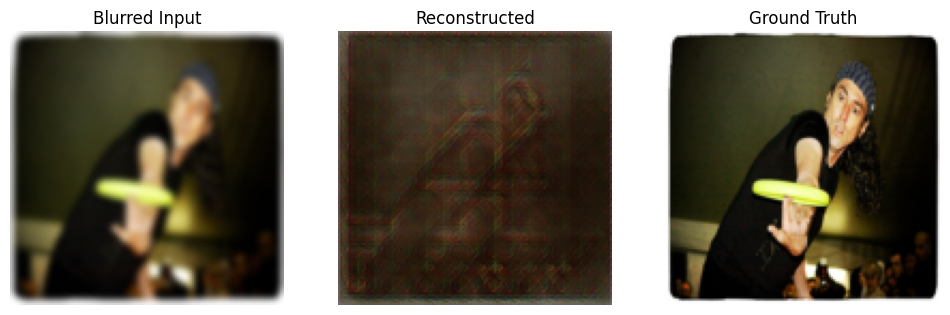

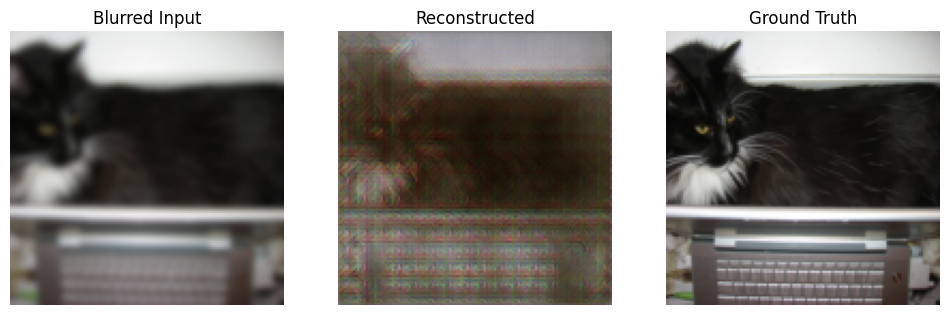

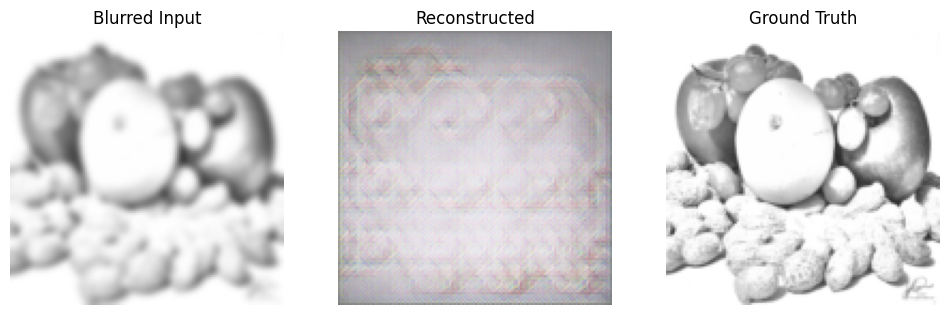

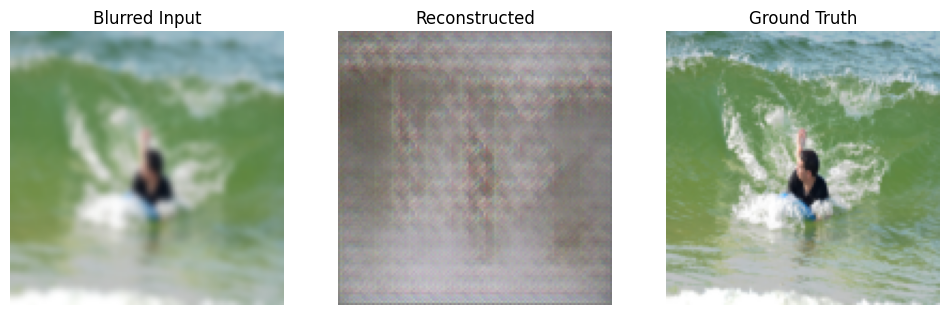

In [29]:
def show_images(inputs, outputs, targets):
    for i in range(len(inputs)):
        fig, axs = plt.subplots(1, 3, figsize=(12, 4))
        axs[0].imshow(inputs[i].permute(1, 2, 0).cpu())
        axs[0].set_title("Blurred Input")
        axs[1].imshow(outputs[i].detach().permute(1, 2, 0).cpu())
        axs[1].set_title("Reconstructed")
        axs[2].imshow(targets[i].permute(1, 2, 0).cpu())
        axs[2].set_title("Ground Truth")
        for ax in axs: ax.axis("off")
        plt.show()

# Run once after training
show_images(blur_tensors, preds, raw_tensors)
